In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

%matplotlib inline

In [4]:
datos = pd.read_csv(filepath_or_buffer = "/Users/paola/Desktop/SA4/comprar_alquilar.csv",sep=',',low_memory=False)

In [5]:
datos

,ingresos,gastos_comunes,pago_coche,gastos_otros,ahorros,vivienda,estado_civil,hijos,trabajo,comprar
0,6000,1000,0,600,50000,400000,0,2,2,1
1,6745,944,123,429,43240,636897,1,3,6,0
2,6455,1033,98,795,57463,321779,2,1,8,1
3,7098,1278,15,254,54506,660933,0,0,3,0
4,6167,863,223,520,41512,348932,0,0,3,1
...,...,...,...,...,...,...,...,...,...,...
197,3831,690,352,488,10723,363120,0,0,2,0
198,3961,1030,270,475,21880,280421,2,3,8,0
199,3184,955,276,684,35565,388025,1,3,8,0
200,3334,867,369,652,19985,376892,1,2,5,0


In [6]:
datos.info()

<class 'pandas.DataFrame'>
RangeIndex: 202 entries, 0 to 201
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   ingresos        202 non-null    int64
 1   gastos_comunes  202 non-null    int64
 2   pago_coche      202 non-null    int64
 3   gastos_otros    202 non-null    int64
 4   ahorros         202 non-null    int64
 5   vivienda        202 non-null    int64
 6   estado_civil    202 non-null    int64
 7   hijos           202 non-null    int64
 8   trabajo         202 non-null    int64
 9   comprar         202 non-null    int64
dtypes: int64(10)
memory usage: 15.9 KB


In [7]:
datos.describe()

,ingresos,gastos_comunes,pago_coche,gastos_otros,ahorros,vivienda,estado_civil,hijos,trabajo,comprar
count,202.000000,202.000000,202.000000,202.000000,202.000000,202.000000,202.000000,202.000000,202.000000,202.000000
mean,4958.995050,971.584158,211.742574,515.425743,38749.668317,373349.638614,1.024752,1.232673,4.490099,0.331683
std,1682.862556,272.106351,124.940754,168.103075,17365.231870,136371.525622,0.837184,1.367833,2.535794,0.471988
min,2008.000000,384.000000,0.000000,201.000000,10319.000000,176553.000000,0.000000,0.000000,0.000000,0.000000
25%,3513.750000,766.750000,99.000000,383.250000,24964.250000,274810.000000,0.000000,0.000000,2.000000,0.000000
50%,4947.500000,968.000000,208.500000,522.500000,38523.000000,340783.500000,1.000000,1.000000,5.000000,0.000000
75%,6374.500000,1165.250000,318.750000,656.750000,52150.750000,444482.000000,2.000000,2.000000,7.000000,1.000000
max,7984.000000,1585.000000,448.000000,828.000000,69934.000000,669540.000000,2.000000,4.000000,8.000000,1.000000


In [8]:
datos.isnull().sum()

ingresos          0
gastos_comunes    0
pago_coche        0
gastos_otros      0
ahorros           0
vivienda          0
estado_civil      0
hijos             0
trabajo           0
comprar           0
dtype: int64

In [9]:
print("Datos duplicados:", datos.duplicated().sum())

Datos duplicados: 0


In [10]:
datos["comprar"].value_counts()

comprar
0    135
1     67
Name: count, dtype: int64

In [11]:
X = datos.drop(columns=["comprar"])
y = datos["comprar"]

print("Características:", X.shape)
print("Variable de referencia:", y.shape)

Características: (202, 9)
Variable de referencia: (202,)


In [12]:
pca_sin_escalar = PCA()

X_pca_sin_escalar = pca_sin_escalar.fit_transform(X)

In [13]:
varianza_sin_escalar = pca_sin_escalar.explained_variance_ratio_

print("Varianza explicada sin escalamiento:")
print(varianza_sin_escalar)

Varianza explicada sin escalamiento:
[9.89863622e-01 1.00647971e-02 6.70050846e-05 2.31716041e-06
 1.46719742e-06 7.90766350e-07 3.78445457e-10 4.26540065e-11
 2.20999821e-11]


In [14]:
varianza_acumulada_sin = np.cumsum(varianza_sin_escalar)

print("Varianza acumulada sin escalamiento:")
print(varianza_acumulada_sin)

Varianza acumulada sin escalamiento:
[0.98986362 0.99992842 0.99999542 0.99999774 0.99999921 1.
 1.         1.         1.        ]


In [15]:
componentes_sin_escalar = pd.DataFrame({
    "PC1": X_pca_sin_escalar[:, 0],
    "PC2": X_pca_sin_escalar[:, 1],
    "Comprar": y.values
})

componentes_sin_escalar

,PC1,PC2,Comprar
0,27451.171886,9176.509662,1
1,263105.304871,-15992.945140,0
2,-49947.652129,22731.258427,1
3,287946.215530,-6632.051619,0
4,-24119.301985,4717.231905,1
...,...,...,...
197,-12384.979911,-27164.720220,0
198,-93963.399879,-9598.820178,0
199,14369.566674,-4407.748811,0
200,2060.978376,-19043.274886,0


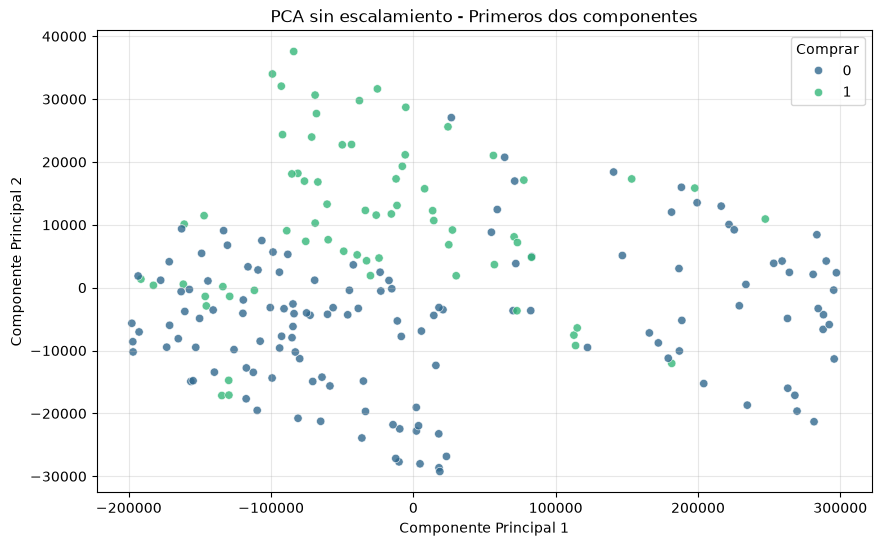

In [16]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=componentes_sin_escalar,
    x="PC1",
    y="PC2",
    hue="Comprar",
    palette="viridis",
    alpha=0.8
)

plt.title("PCA sin escalamiento - Primeros dos componentes")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.legend(title="Comprar")
plt.grid(alpha=0.3)

plt.show()

In [17]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled

array([[ 0.62012866,  0.10468863, -1.69895439, ..., -1.22708822,
         0.5623736 , -0.98441983],
       [ 1.0639266 , -0.10162457, -0.71204191, ..., -0.02963981,
         1.29527339,  0.59691461],
       [ 0.89117304,  0.22626604, -0.91263388, ...,  1.1678086 ,
        -0.17052619,  1.38758182],
       ...,
       [-1.05736798, -0.06109876,  0.51558094, ..., -0.02963981,
         1.29527339,  1.38758182],
       [-0.96801269, -0.38530521,  1.26178306, ..., -0.02963981,
         0.5623736 ,  0.201581  ],
       [-0.57842363,  0.68310241, -0.85646812, ..., -1.22708822,
        -0.90342598, -0.19375261]], shape=(202, 9))

In [18]:
pca_escalado = PCA()

X_pca_escalado = pca_escalado.fit_transform(X_scaled)

In [19]:
varianza_escalada = pca_escalado.explained_variance_ratio_

print("Varianza explicada con escalamiento:")
print(varianza_escalada)

Varianza explicada con escalamiento:
[0.29913557 0.23294923 0.11711241 0.10685622 0.09635279 0.05629866
 0.04145579 0.03017819 0.01966115]


In [20]:
varianza_acumulada = np.cumsum(varianza_escalada)

print("Varianza acumulada:")
print(varianza_acumulada)

Varianza acumulada:
[0.29913557 0.5320848  0.64919721 0.75605343 0.85240621 0.90870487
 0.95016066 0.98033885 1.        ]


In [21]:
tabla_varianza = pd.DataFrame({
    "Componente": [
        f"PC{i+1}"
        for i in range(len(varianza_escalada))
    ],
    "Varianza explicada": varianza_escalada,
    "Varianza acumulada": varianza_acumulada
})

tabla_varianza

,Componente,Varianza explicada,Varianza acumulada
0,PC1,0.299136,0.299136
1,PC2,0.232949,0.532085
2,PC3,0.117112,0.649197
3,PC4,0.106856,0.756053
4,PC5,0.096353,0.852406
5,PC6,0.056299,0.908705
6,PC7,0.041456,0.950161
7,PC8,0.030178,0.980339
8,PC9,0.019661,1.000000


In [22]:
componentes_escalados = pd.DataFrame({
    "PC1": X_pca_escalado[:, 0],
    "PC2": X_pca_escalado[:, 1],
    "Comprar": y.values
})

componentes_escalados

,PC1,PC2,Comprar
0,1.321915,-0.222950,1
1,1.147878,1.716967,0
2,0.090369,1.836066,1
3,3.455898,-0.078279,0
4,0.916933,-1.184676,1
...,...,...,...
197,-0.707036,-2.506168,0
198,-2.038917,1.378909,0
199,-1.481464,0.975900,0
200,-1.514633,-0.392176,0


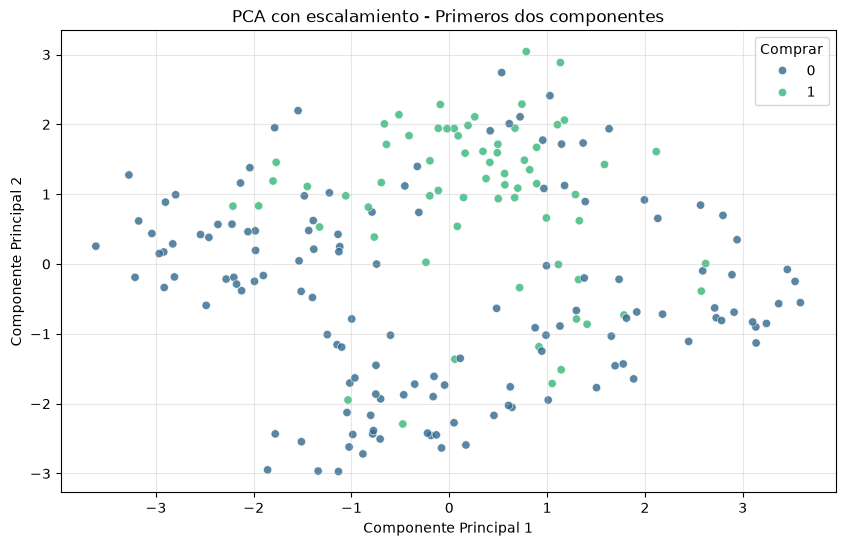

In [23]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=componentes_escalados,
    x="PC1",
    y="PC2",
    hue="Comprar",
    palette="viridis",
    alpha=0.8
)

plt.title("PCA con escalamiento - Primeros dos componentes")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.legend(title="Comprar")
plt.grid(alpha=0.3)

plt.show()

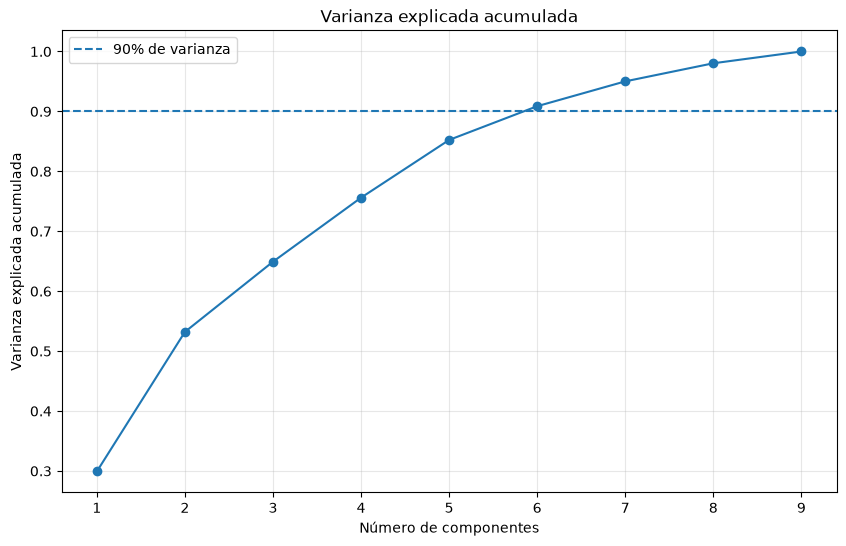

In [24]:
plt.figure(figsize=(10, 6))

componentes = range(
    1,
    len(varianza_acumulada) + 1
)

plt.plot(
    componentes,
    varianza_acumulada,
    marker="o"
)

plt.axhline(
    y=0.90,
    linestyle="--",
    label="90% de varianza"
)

plt.title("Varianza explicada acumulada")
plt.xlabel("Número de componentes")
plt.ylabel("Varianza explicada acumulada")
plt.xticks(componentes)
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [25]:
numero_componentes = np.argmax(
    varianza_acumulada >= 0.90
) + 1

print(
    "Número de componentes para conservar al menos 90% de la varianza:",
    numero_componentes
)

print(
    "Varianza conservada:",
    varianza_acumulada[numero_componentes - 1]
)

Número de componentes para conservar al menos 90% de la varianza: 6
Varianza conservada: 0.9087048736637353


In [26]:
pca_final = PCA(
    n_components=numero_componentes
)

X_reducido = pca_final.fit_transform(
    X_scaled
)

X_reducido.shape

(202, 6)

In [27]:
columnas_componentes = [
    f"PC{i+1}"
    for i in range(numero_componentes)
]

datos_reducidos = pd.DataFrame(
    X_reducido,
    columns=columnas_componentes
)

datos_reducidos["comprar"] = y.values

datos_reducidos

,PC1,PC2,PC3,PC4,PC5,PC6,comprar
0,1.321915,-0.222950,1.599863,-0.885014,0.646617,-0.700208,1
1,1.147878,1.716967,0.395722,-0.447960,-0.687805,-0.231969,0
2,0.090369,1.836066,1.359382,0.337505,0.742387,0.593030,1
3,3.455898,-0.078279,-0.202382,-1.573584,-0.068551,-0.051945,0
4,0.916933,-1.184676,0.190036,0.117804,-0.147753,-0.619750,1
...,...,...,...,...,...,...,...
197,-0.707036,-2.506168,-0.430903,0.583919,-0.620195,-0.205709,0
198,-2.038917,1.378909,-0.824921,0.039240,0.373044,0.013360,0
199,-1.481464,0.975900,0.637578,0.884946,0.128337,-0.655749,0
200,-1.514633,-0.392176,0.005710,1.308566,-0.114526,-0.056951,0


In [28]:
datos_reducidos.to_csv(
    "datos_reducidos_comprar_alquilar.csv",
    index=False
)

print("Datos reducidos guardados correctamente")

Datos reducidos guardados correctamente


In [29]:
modelo_final = {
    "scaler": scaler,
    "pca": pca_final
}

joblib.dump(
    modelo_final,
    "modelo_pca_comprar_alquilar.pkl"
)

print("Modelo PCA guardado correctamente")

Modelo PCA guardado correctamente


In [30]:
modelo_cargado = joblib.load(
    "modelo_pca_comprar_alquilar.pkl"
)

scaler_cargado = modelo_cargado["scaler"]
pca_cargado = modelo_cargado["pca"]

X_scaled_prueba = scaler_cargado.transform(X)

X_reducido_prueba = pca_cargado.transform(
    X_scaled_prueba
)

print(
    "Dimensiones después de cargar el modelo:",
    X_reducido_prueba.shape
)

Dimensiones después de cargar el modelo: (202, 6)
